In [1]:
using Pkg
Pkg.activate("/Users/alia/Desktop/envs/ants")
using Plots
using DifferentialEquations
using LaTeXStrings
using NLsolve
using IntervalArithmetic, IntervalArithmetic.Symbols, IntervalRootFinding
using LinearAlgebra
using Plots.PlotMeasures

  Activating project at `~/Desktop/envs/ants`


In [2]:
pythonplot()

Plots.PythonPlotBackend()

In [3]:
pal = palette(:default)

### SIS style version
with reinfection rate $\gamma$

In [ ]:
function model_7d_t(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,B,C,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    Sdot = (-(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S) + gamma*H
        # + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n))
    Cdot = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    Bdot = alphaB*(1+xB)*S - omegaB*B/(1+ (C/k)^n)
    Tdot = alphaT*(1+xT)*S - beta*T
    xCdot = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C)))
    xBdot = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C)))
    xTdot = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C)))

    [
        Sdot
        Bdot
        Cdot
        Tdot
        xCdot
        xBdot
        xTdot
    ]
end

function gimmie_gamma_norm(t)
    gamma = 0
    if t>100 && t < 150
        gamma = 1
    #elseif t>170 && t<200
    #    gamma = 1
    else
        gamma = 0
    end

    return gamma
end

function model_7d_t_sin(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,B,C,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    Sdot = (-(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S) + gamma*H*gimmie_gamma_norm(t)
        # + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n))
    Cdot = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    Bdot = alphaB*(1+xB)*S - omegaB*B/(1+ (C/k)^n)
    Tdot = alphaT*(1+xT)*S - beta*T
    xCdot = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C)))
    xBdot = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C)))
    xTdot = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C)))

    [
        Sdot
        Bdot
        Cdot
        Tdot
        xCdot
        xBdot
        xTdot
    ]
end

function model_4d_t(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,B,C,T = x
    H = 1 - S - B - C - T
    Sdot = (-(alphaC+alphaB+alphaT)*S) + gamma*H
    Cdot = alphaC*S - omegaC*C/(1+ (C/k)^n)
    Bdot = alphaB*S - omegaB*B/(1+ (C/k)^n)
    Tdot = alphaT*S - beta*T
    HHdot = H

    [
        Sdot
        Bdot
        Cdot
        Tdot
    ]
end

model_4d_t (generic function with 1 method)

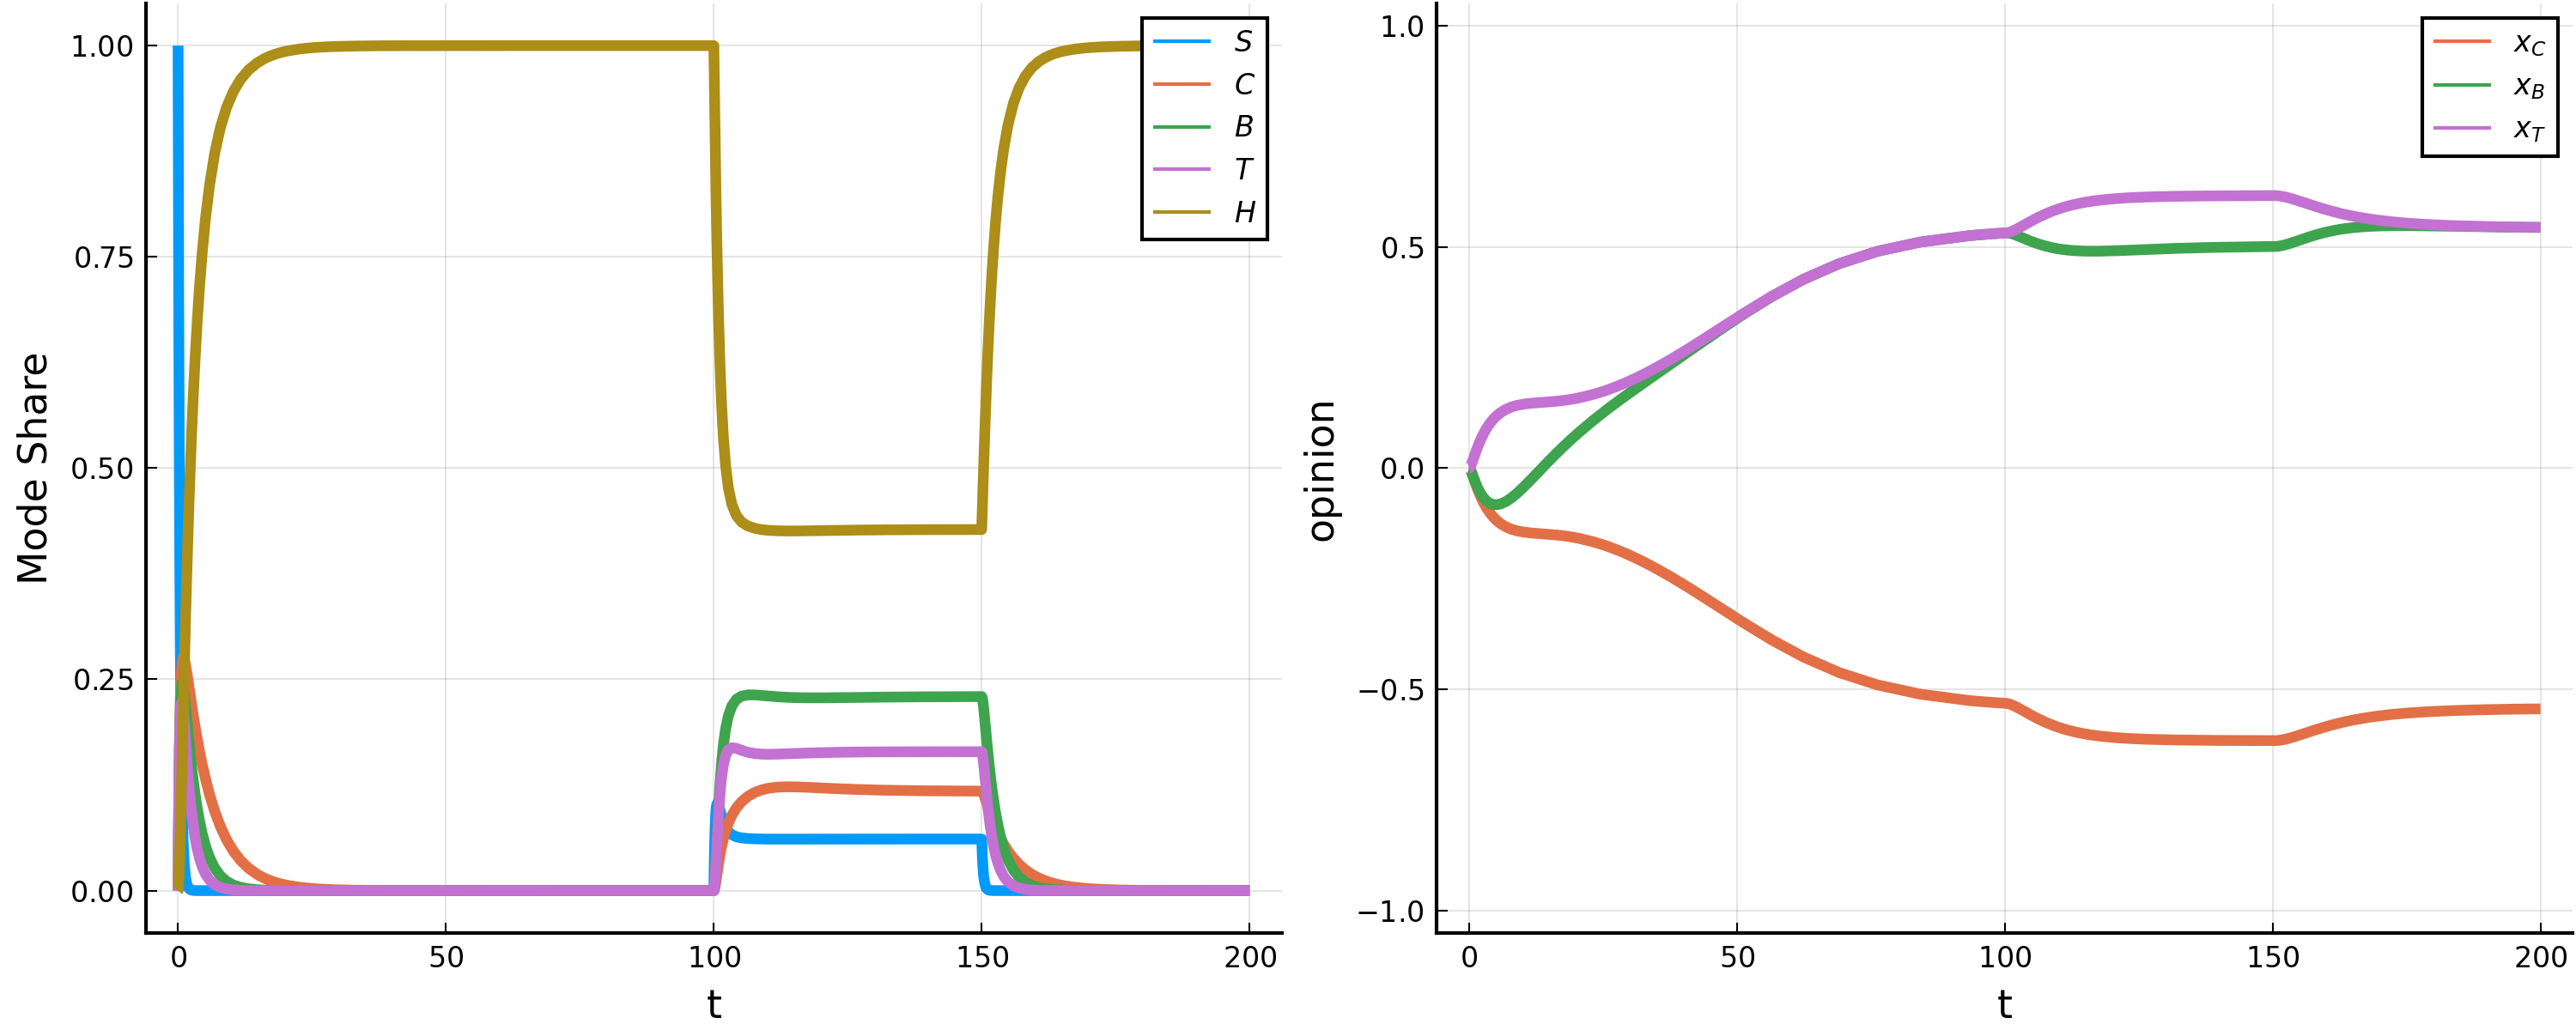

In [5]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.5)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau = par
u0 = [1.0,0.0,0.0,0.0,0.0, 0.0,0.0]
tspan=(0.0,200.0)

prob_7d = ODEProblem(model_7d_t_sin,u0,tspan,par)
sol7d = DifferentialEquations.solve(prob_7d)
S,B,C,T,xC,xB,xT = sol7d[1,:],sol7d[2,:],sol7d[3,:],sol7d[4,:],sol7d[5,:],sol7d[6,:],sol7d[7,:]
H = 1 .- S .- C .- B .-T

pal = palette(:default)

p1 = plot(sol7d.t, vec(S), label = L"S",  lw=3, ylims=(-0.05,1.05), color = pal[1],xlabel = "t",ylabel = "Mode Share")
plot!(p1, sol7d.t, vec(C), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol7d.t, vec(B), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol7d.t, vec(T), label = L"T",   lw=3, color = pal[4])
plot!(p1, sol7d.t, vec(H), label = L"H",   lw=3, color = pal[5])

p2 = plot(sol7d.t, vec(xC), label = L"x_C", lw=3, ylims=(-1.05,1.05), color = pal[2],xlabel ="t",ylabel = "opinion")
plot!(p2, sol7d.t, vec(xB), label = L"x_B", lw=3, color = pal[3])
plot!(p2, sol7d.t, vec(xT), label = L"x_T", lw=3, color = pal[4])

FIG = plot(p1, p2, size=(1000,400),dpi = 300,left_margin = 5mm)
#png(FIG,"temporary_gamma")

┌ Warning: Could not infer the return type of the function (it may be type instable). Got Any
└ @ IntervalRootFinding /Users/alia/.julia/packages/IntervalRootFinding/bCqSv/src/roots.jl:69


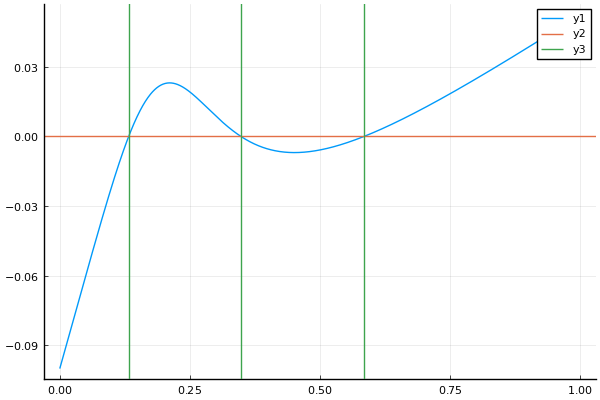

In [6]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.25,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par
A = omegaC/alphaC * (alphaC + alphaB + alphaT + gamma + gamma*alphaT/beta)
D = gamma * (1 + (omegaC*alphaB)/(omegaB*alphaC))

function equilibrium(C)
    return float(A*(C/(1 + (C/k)^n)) - gamma + D*C)
end

C_star =[]
roots_sol = roots(equilibrium,0..1)
for result in roots_sol
    if result.status == :unique
        push!(C_star,0.5 * (sup(result.region) +inf(result.region)))
    end
end

x = range(0.0, 1, length=1000)
y = @. equilibrium(x)

plot(x,y)
hline!([0])
vline!([C_star])

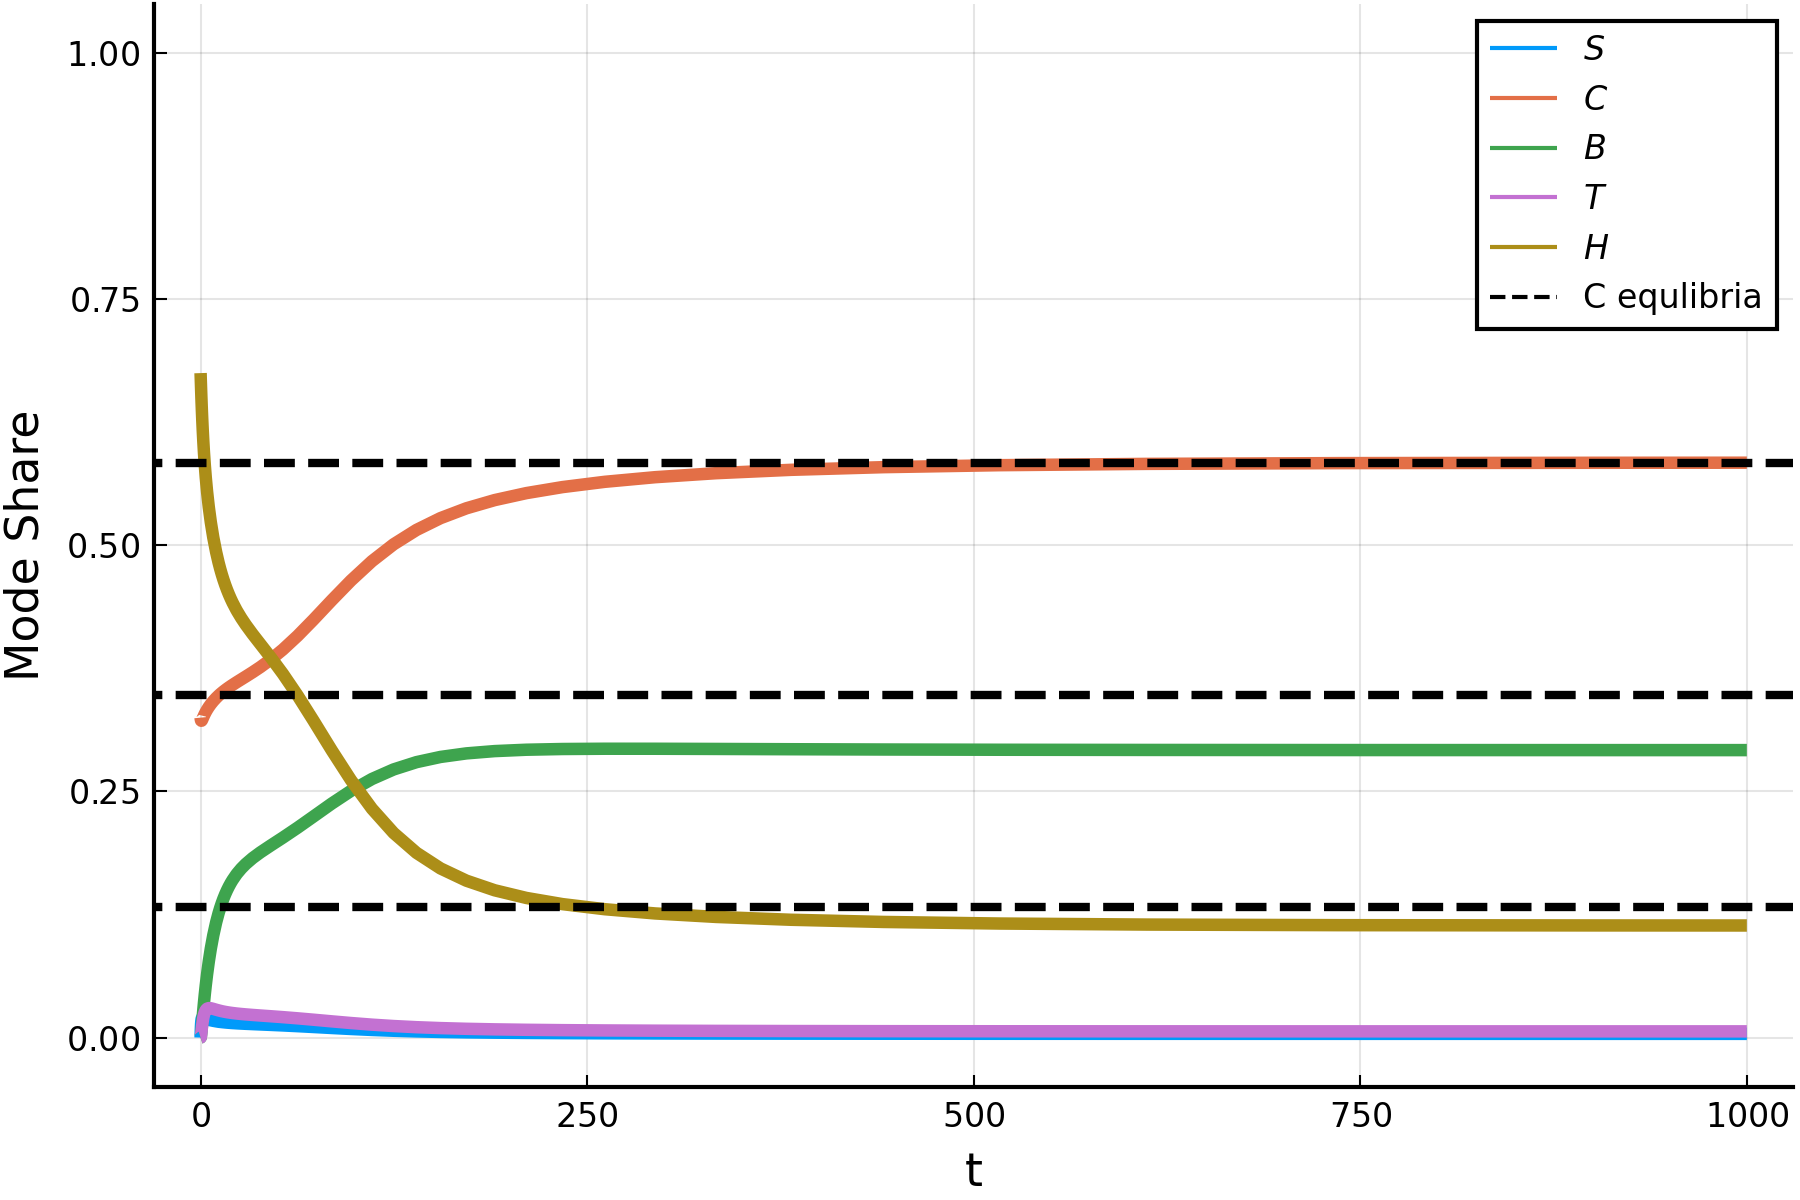

In [7]:
#par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,k=0.4,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)

u0 = [0.0,0.0,0.325,0.0]
tspan=(0.0,1000.0)

prob_4d = ODEProblem(model_4d_t,u0,tspan,par)
sol4d = DifferentialEquations.solve(prob_4d)
S,B,C,T = sol4d[1,:],sol4d[2,:],sol4d[3,:],sol4d[4,:]
H = 1 .- S .- C .- B .-T

pal = palette(:default)

p1 = plot(sol4d.t, vec(S), label = L"S",  lw=3, ylims=(-0.05,1.05), color = pal[1],xlabel = "t",ylabel = "Mode Share",dpi=300)
plot!(p1, sol4d.t, vec(C), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol4d.t, vec(B), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol4d.t, vec(T), label = L"T",   lw=3, color = pal[4])
plot!(p1, sol4d.t, vec(H), label = L"H",   lw=3, color = pal[5])
hline!(C_star, label = "C equlibria", linestyle = :dash,lw = 2, color = "black")

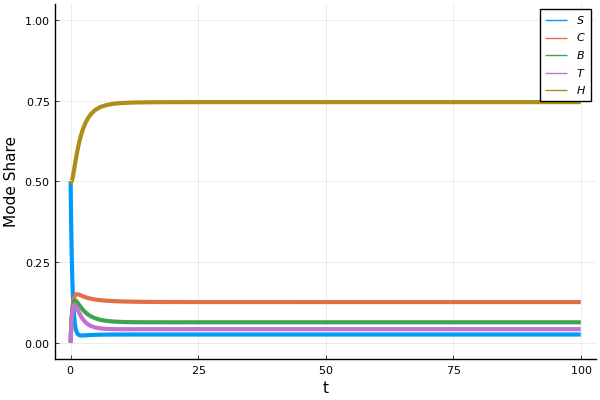

In [91]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.4,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par
u0 = [0.5,0.0,0.0,0.0]
tspan=(0.0,100.0)

prob_4d = ODEProblem(model_4d_t,u0,tspan,par)
sol4d = DifferentialEquations.solve(prob_4d)
S4,B4,C4,T4 = sol4d[1,:],sol4d[2,:],sol4d[3,:],sol4d[4,:]
H4 = 1 .- S4 .- C4 .- B4 .-T4

pal = palette(:default)

p1 = plot(sol4d.t, vec(S4), label = L"S",  lw=3, ylims=(-0.05,1.05), color = pal[1],xlabel = "t",ylabel = "Mode Share")
plot!(p1, sol4d.t, vec(C4), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol4d.t, vec(B4), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol4d.t, vec(T4), label = L"T",   lw=3, color = pal[4])
plot!(p1, sol4d.t, vec(H4), label = L"H",   lw=3, color = pal[5])

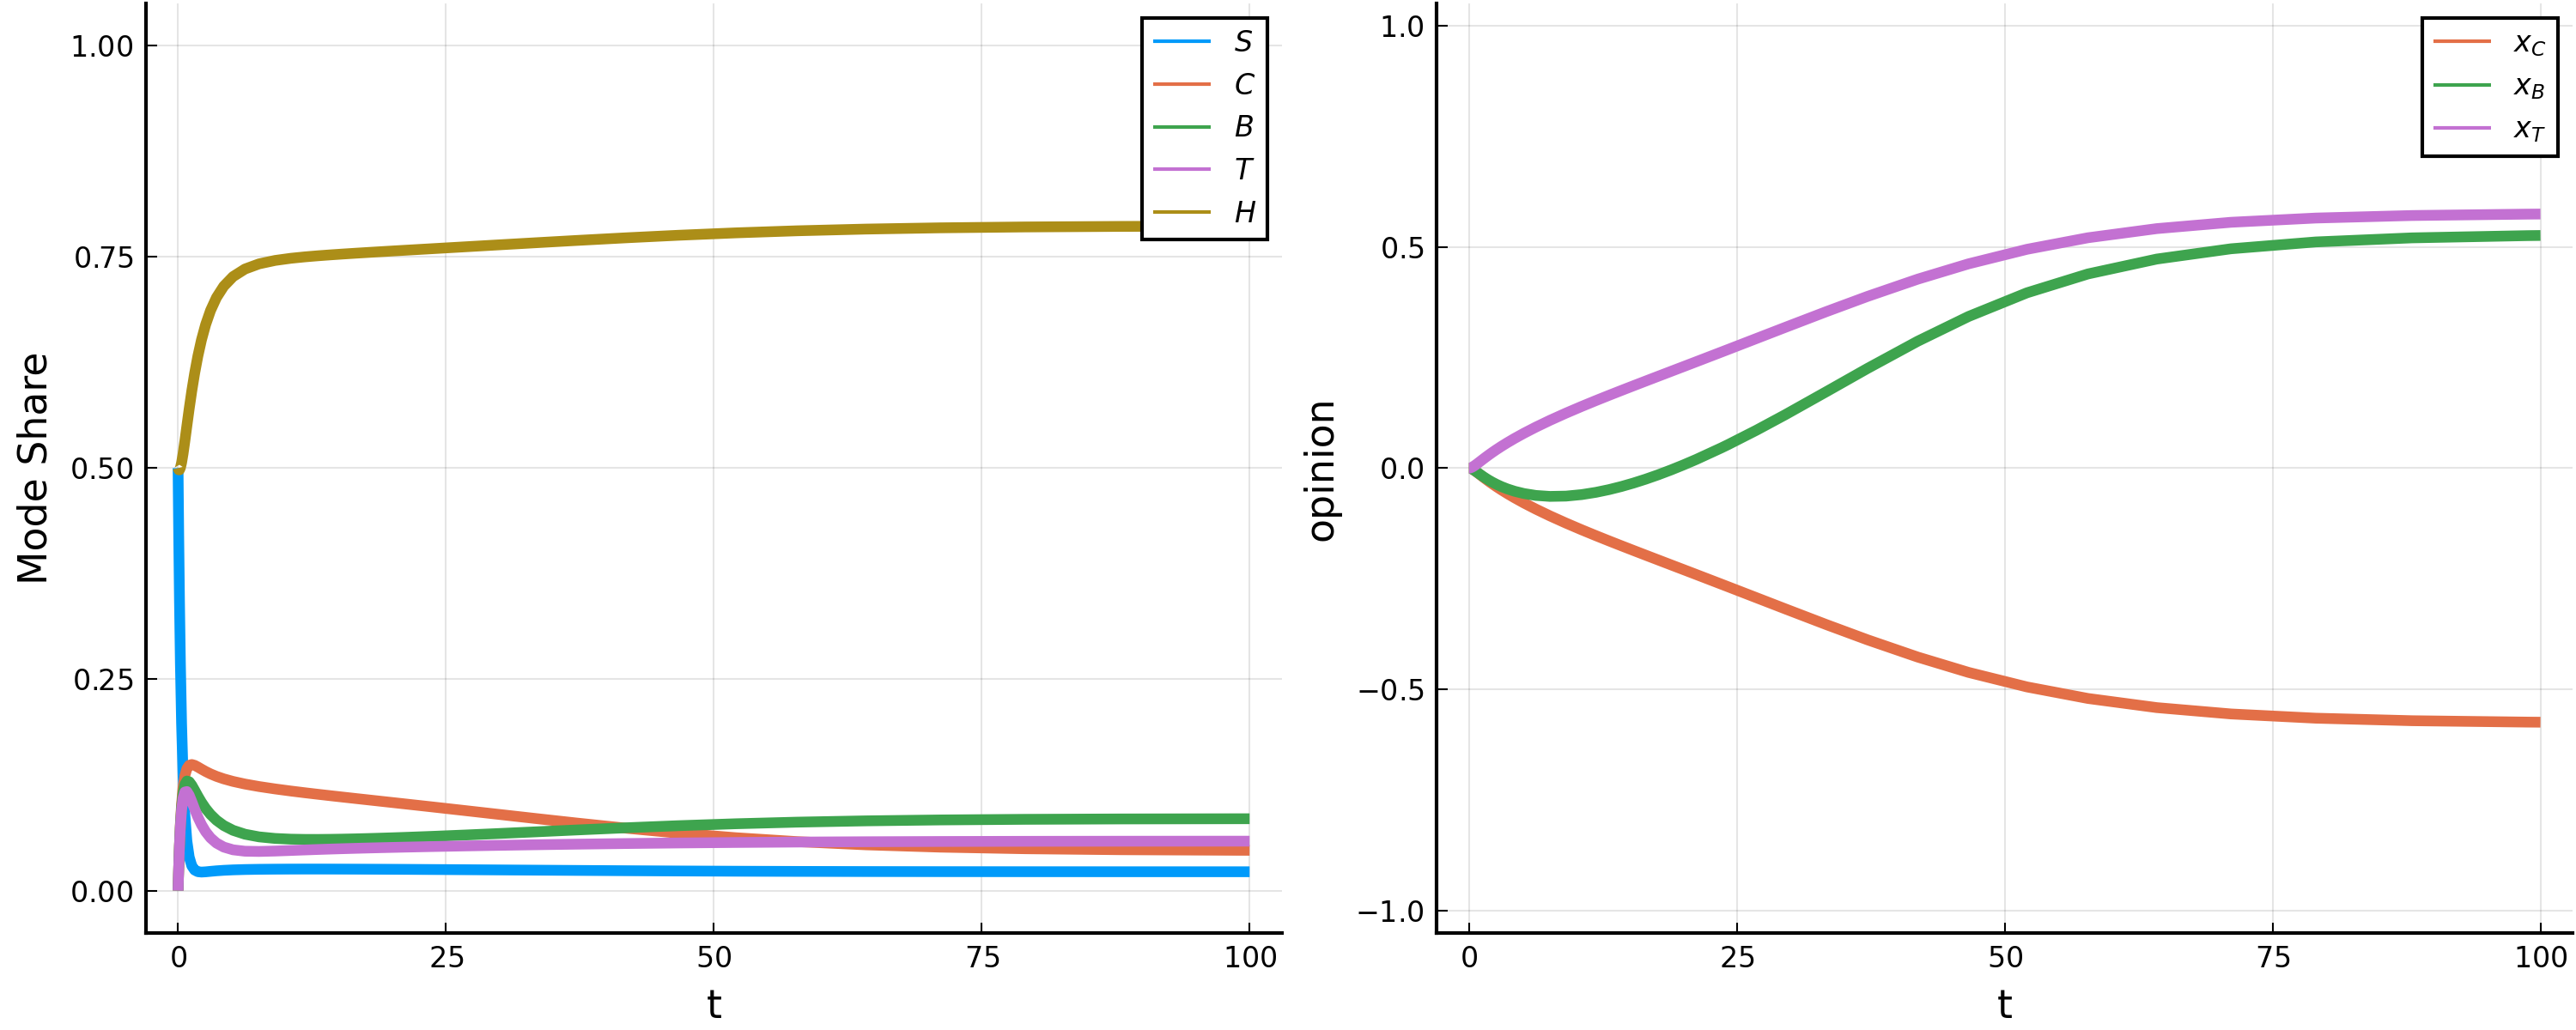

In [96]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.4,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 1,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par


par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
    k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par

u0 = [0.5,0.0,0.0,0.0,0.0,0.0,0.0]

prob_7d = ODEProblem(model_7d_t,u0,tspan,par)
sol7d = DifferentialEquations.solve(prob_7d)
S,B,C,T,xC,xB,xT = sol7d[1,:],sol7d[2,:],sol7d[3,:],sol7d[4,:],sol7d[5,:],sol7d[6,:],sol7d[7,:]
H = 1 .- S .- C .- B .-T

pal = palette(:default)

p1 = plot(sol7d.t, vec(S), label = L"S",  lw=3, ylims=(-0.05,1.05), color = pal[1],xlabel = "t",ylabel = "Mode Share")
plot!(p1, sol7d.t, vec(C), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol7d.t, vec(B), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol7d.t, vec(T), label = L"T",   lw=3, color = pal[4])
plot!(p1, sol7d.t, vec(H), label = L"H",   lw=3, color = pal[5])

p2 = plot(sol7d.t, vec(xC), label = L"x_C", lw=3, ylims=(-1.05,1.05), color = pal[2],xlabel ="t",ylabel = "opinion")
plot!(p2, sol7d.t, vec(xB), label = L"x_B", lw=3, color = pal[3])
plot!(p2, sol7d.t, vec(xT), label = L"x_T", lw=3, color = pal[4])

FIG = plot(p1, p2, size=(1000,400),dpi = 300,left_margin = 5mm)

In [95]:
println(S[end],B[end],C[end],T[end],xC[end],xB[end],xT[end])

0.0248843913272754280.0624134300710747560.124826552623896040.04150013222529302-0.0006304423107703057-0.00062788991184939660.0006304423107703055


In [10]:
function trapz(x,y)
    N = length(x)
    I = sum([(x[i]-x[i-1])*(y[i-1]+y[i])/2 for i in 2:N])
    return I
end

println(trapz([1,2,3,4,5],[1,4,9,16,25])) # should return 42 if working correctly

# possible cost functions. Reward "happy" H and penalize cars

function costlin(x,H,C,a1,a2)
    return (-a1*trapz(x,H) + a2*trapz(x,C))/(x[end]-x[1])
end

function costquad(x,H,C,a1,a2)
    return (-a1*trapz(x,H.^2) + a2*trapz(x,C.^2))/(x[end]-x[1])
end

function costmult(x,H,C)
    return trapz(x,H .* (1 .- C))/(x[end]-x[1])
end

function costlinparam(x,H,C,a1,a2,a3,alphaC,alphaB,alphaT)
    return (-a1*trapz(x,H) + a2*trapz(x,C))/(x[end]-x[1]) + a3*(alphaC+alphaB+alphaT)
end

function costlinparamNOD(x,H,C,a1,a2,a3,alphaC,alphaB,alphaT,xC,xB,xT)
    return (-a1*trapz(x,H) + a2*trapz(x,C) + a3 * trapz(x,(alphaC*(1 .+ xC) + alphaB*(1 .+ xB) + alphaT*(1 .+ xT))))/(x[end]-x[1])
end

a1 = 1
a2 = 1
a3 = 0.1
println((alphaC+alphaB+alphaT))
#println(costlinparamNOD(sol7d.t,H,C,a1,a2,a3,alphaC,alphaB,alphaT,xC,xB,xT))

42.0
3.0


In [11]:
println(costlin(sol4d.t,H4,C4,a1,a2))
println(costquad(sol4d.t,H4,C4,a1,a2))
println(costmult(sol4d.t,H4,C4))
println(costlinparam(sol4d.t,H4,C4,a1,a2,a3,alphaC,alphaB,alphaT))

-0.6070833487263589
-0.5240944988287753
0.6408588106211809
-0.3070833487263589


In [12]:

println(costlin(sol7d.t,H,C,a1,a2))
println(costquad(sol7d.t,H,C,a1,a2))
println(costmult(sol7d.t,H,C))
#println(costlinparam(sol7d.t,H,C,a1,a2,a3,alphaC,alphaB,alphaT))
println(costlinparamNOD(sol7d.t,H,C,a1,a2,a3,alphaC,alphaB,alphaT,xC,xB,xT))

-0.6913390713145158
-0.5778778157322595
0.7092913841241686
-0.35420505244389394


In [25]:
function model_7d_in_out(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,B,C,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    Sdot = (-(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S) + gamma*H
        # + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n))
    Cdot = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    Bdot = alphaB*(1+xB)*S - omegaB*B/(1+ (C/k)^n)
    Tdot = alphaT*(1+xT)*S - beta*T
    xCdot = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C)))
    xBdot = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C)))
    xTdot = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C)))
    SIN = gamma*H
    HIN = (omegaC*C + omegaB*B)/(1+ (C/k)^n) + beta*T

    [
        Sdot
        Bdot
        Cdot
        Tdot
        xCdot
        xBdot
        xTdot
        SIN
        HIN
    ]
end


function model_4d_in_out(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,B,C,T = x
    H = 1 - S - B - C - T
    Sdot = (-(alphaC+alphaB+alphaT)*S) + gamma*H
    Cdot = alphaC*S - omegaC*C/(1+ (C/k)^n)
    Bdot = alphaB*S - omegaB*B/(1+ (C/k)^n)
    Tdot = alphaT*S - beta*T
    SIN = gamma*H
    HIN = (omegaC*C + omegaB*B)/(1+ (C/k)^n) + beta*T

    [
        Sdot
        Bdot
        Cdot
        Tdot
        SIN
        HIN
    ]
end

model_4d_in_out (generic function with 1 method)

In [75]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.4,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par
u0 = [1.0,0.0,0.0,0.0,0.0,0.0]
tspan=(0.0,100.0)

prob_4d = ODEProblem(model_4d_in_out,u0,tspan,par)
sol4d = DifferentialEquations.solve(prob_4d)
S4,B4,C4,T4,Sin,Hin = sol4d[1,:],sol4d[2,:],sol4d[3,:],sol4d[4,:],sol4d[5,:],sol4d[6,:]
H4 = 1 .- S4 .- C4 .- B4 .-T4;
println(Hin[end])

7.997676047337837


In [85]:
us = LinRange(0.01,4,500)
u0 = [1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]
y1=[]
y2=[]
y3=[]
y4=[]
Sins = []
Hins = []

#(alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,k=0.5,n=4,u=u,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3)

for u in us
    par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.5,n=4,u=u,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
    prob = ODEProblem(model_7d_in_out,u0,tspan,par)
    sol = DifferentialEquations.solve(prob)
    S,B,C,T,xC,xB,xT,Sin,Hin = sol[1,:],sol[2,:],sol[3,:],sol[4,:],sol[5,:],sol[6,:],sol[7,:],sol[8,:],sol[9,:]
    H = 1 .- S .- C .- B .-T

    push!(y1,costlin(sol.t,H,C,a1,a2))
    push!(y2,costquad(sol.t,H,C,a1,a2))
    push!(y3,costmult(sol.t,H,C))
    push!(y4,costlinparamNOD(sol.t,H,C,a1,a2,a3,alphaC,alphaB,alphaT,xC,xB,xT))
    push!(Sins, Sin[end])
    push!(Hins, Hin[end])
end

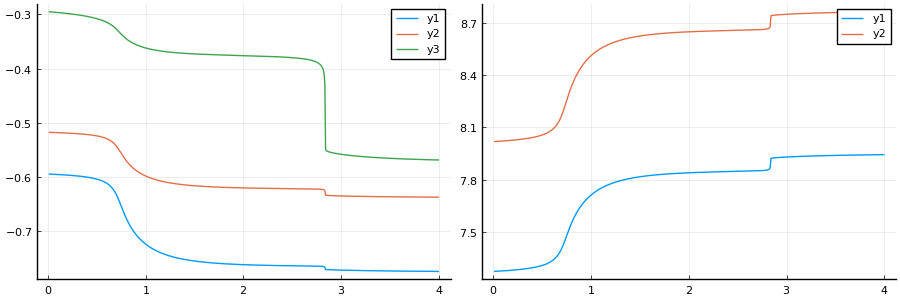

In [86]:
p1=plot(us,[y1,y2,y4])
p2 = plot(us,[Sins,Hins])
plot(p1,p2,layout = 2,size = (900,300))

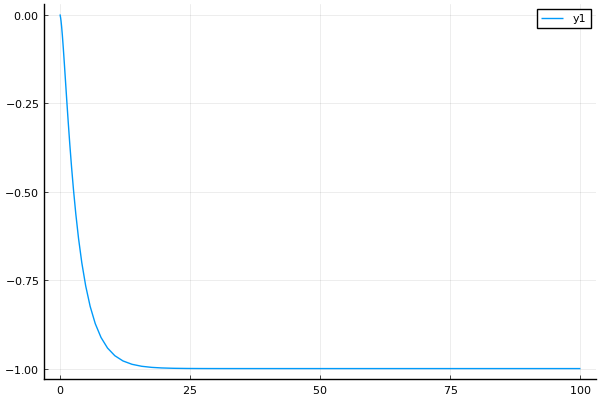

In [87]:
plot(sol.t,xC)